In [ ]:
import torch
import warnings
import tonic
import matplotlib.pyplot    as plt
import torch.nn.functional  as F
import snntorch.spikeplot   as splt
import tonic.datasets       as datasets
import snntorch             as snn
import torch.nn             as nn
import numpy                as np

from IPython.display        import HTML
from tqdm                   import tqdm
from snntorch.spikevision   import spikedata
from torch.utils.data       import Dataset, DataLoader
from tonic                  import transforms
from tonic                  import transforms as tonic_transforms

warnings.filterwarnings("ignore")

# create datasets
train_ds = spikedata.DVSGesture("dataset/dvsgesture", train=True)
test_ds = spikedata.DVSGesture("dataset/dvs_gesture", train=False)

# create dataloaders
train_dl = DataLoader(train_ds, shuffle=True, batch_size=64)
test_dl = DataLoader(test_ds, shuffle=False, batch_size=64)

# choose a sample index (DVSGesture has many samples; make sure n is in range)
n = 125

# --- Tonic: convert events -> frames ---
sensor_size = datasets.DVSGesture.sensor_size
frame_transform = transforms.ToFrame(sensor_size=sensor_size, time_window=50_000)  # 50ms

train_ds = datasets.DVSGesture(save_to="./dataset", train=True, transform=frame_transform)

# (DataLoader isn't required for indexing, but kept like your original code)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# --- Load ONE sample (frames, label) ---
frames, label = train_dl.dataset[n]   # frames is numpy array: [T, 2, H, W]

# Convert to torch tensor so snntorch animator can call .size()
frames = torch.from_numpy(frames).float()  # [T,2,H,W]

# Sum ON/OFF polarity channels -> [T, H, W]
a = frames[:, 0] + frames[:, 1]

# --- Plot / animate ---
fig, ax = plt.subplots()
anim = splt.animator(a, fig, ax, interval=10)

HTML(anim.to_html5_video())

# --- Save video (requires ffmpeg installed in Colab runtime) ---
# !apt-get -qq install -y ffmpeg
anim.save("dvsgesture_animator.mp4", writer="ffmpeg", fps=50)

# =============================================================
# FULL, CORRECT, Colab-ready code for:
#   - Spiking Heidelberg Digits (SHD)
#   - Spiking Speech Commands (SSC)
#
# Uses tonic datasets + your pipeline:
#   events -> ToFrame -> [T,700] -> aggregate -> [700] in [0,1]
#   -> stochastic_rate_encode -> SoftwareSNN / HardwareSNN evaluation
#
# IMPORTANT:
# - Use num_workers=0 in Colab (prevents multiprocessing issues)
# - OUTPUT_SIZE: SHD=20, SSC=35
# =============================================================

# =========================
# Choose dataset
# =========================
DATASET_NAME = "SHD"     # "SHD" or "SSC"
ROOT_DIR     = "./dataset_hsd"

# =========================
# General setup
# =========================
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
USE_SC_DECAY = True
SC_LENGTH    = 256

# =========================
# Configuration
# =========================
INPUT_SIZE   = 256
HIDDEN_SIZE  = 256

if DATASET_NAME.upper() == "SHD":
    OUTPUT_SIZE = 20
elif DATASET_NAME.upper() == "SSC":
    OUTPUT_SIZE = 35
else:
    raise ValueError("DATASET_NAME must be 'SHD' or 'SSC'")

TIME_STEPS   = 10
BATCH_SIZE   = 128
EPOCHS       = 70
LR           = 1e-3

THRESHOLD    = torch.tensor(1.0, device=DEVICE)
BETA         = torch.tensor(0.98, device=DEVICE)
ALPHA        = torch.tensor(0.90, device=DEVICE)

# =========================
# Fixed-point state config (hardware sim)
# =========================
USE_FIXED_STATES = True
FIXED_TOTAL_BITS = 16
FIXED_FRAC_BITS  = 7
FIXED_ADD_MODE   = "saturate"

# =========================
# Seeds
# =========================
def set_seed(seed: int = 0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(0)

# =============================================================
# Stochastic Computing helpers (unipolar)
# =============================================================
def sc_unipolar_mul(a: torch.Tensor, b: torch.Tensor, L: int = SC_LENGTH) -> torch.Tensor:
    a = a.clamp(0.0, 1.0)
    b = b.clamp(0.0, 1.0)
    shape = torch.broadcast_shapes(a.shape, b.shape)
    a_exp = a.expand(shape)
    b_exp = b.expand(shape)
    U1 = torch.rand((L,) + shape, device=a.device)
    U2 = torch.rand((L,) + shape, device=a.device)
    S1 = (U1 < a_exp)
    S2 = (U2 < b_exp)
    return (S1 & S2).float().mean(dim=0)

def sc_unipolar_scale(x: torch.Tensor, s: torch.Tensor, L: int = SC_LENGTH) -> torch.Tensor:
    return sc_unipolar_mul(x, s, L)

def to_unipolar(x: torch.Tensor, lo: float = 0.0, hi: float = 1.0) -> torch.Tensor:
    return ((x - lo) / max(1e-8, hi - lo)).clamp(0.0, 1.0)

def from_unipolar(p: torch.Tensor, lo: float = 0.0, hi: float = 1.0) -> torch.Tensor:
    return p * (hi - lo) + lo

# =============================================================
# Rate encoder (your pipeline expects static [B,N] -> spikes [T,B,N])
# =============================================================
def stochastic_rate_encode(x: torch.Tensor, num_steps: int = TIME_STEPS) -> torch.Tensor:
    x = x.float().unsqueeze(1).expand(-1, num_steps, -1)      # [B,T,N]
    return (torch.rand_like(x) < x).float().permute(1, 0, 2)  # [T,B,N]

# =============================================================
# Fixed-point helpers (minimal, correct)
# =============================================================
def float_to_fixed(x: torch.Tensor, total_bits: int = 16, frac_bits: int = 15) -> torch.Tensor:
    max_val = (1 << (total_bits - 1)) - 1
    min_val = -(1 << (total_bits - 1))
    scale = 1 << frac_bits
    fixed = (x * scale).round().clamp(min_val, max_val)
    return fixed.to(torch.int32)

def fixed_to_float(x: torch.Tensor, frac_bits: int = 15) -> torch.Tensor:
    return x.to(torch.float32) / float(1 << frac_bits)

def _signed_limits(nbits: int):
    maxv = (1 << (nbits - 1)) - 1
    minv = -(1 << (nbits - 1))
    return minv, maxv

def _wrap_to_nbits(x: torch.Tensor, nbits: int) -> torch.Tensor:
    mask = (1 << nbits) - 1
    x = x.to(torch.int64) & mask
    sign_bit = 1 << (nbits - 1)
    x = torch.where(x >= sign_bit, x - (1 << nbits), x)
    return x.to(torch.int64)

def fixed_add(a_int: torch.Tensor, b_int: torch.Tensor, nbits: int, mode: str = "saturate") -> torch.Tensor:
    s = a_int.to(torch.int64) + b_int.to(torch.int64)
    if mode == "wrap":
        return _wrap_to_nbits(s, nbits).to(torch.int32)
    minv, maxv = _signed_limits(nbits)
    return s.clamp(minv, maxv).to(torch.int32)

def fixed_sub(a_int: torch.Tensor, b_int: torch.Tensor, nbits: int, mode: str = "saturate") -> torch.Tensor:
    return fixed_add(a_int, -b_int.to(torch.int64), nbits=nbits, mode=mode)

# =============================================================
# Dataset wrapper: SHD/SSC -> static [700] in [0,1]
# This FIXES your errors:
# - Handles shapes like (1,1,700) returned by tonic ToFrame in some versions
# - Implements __getitem__ properly
# =============================================================
class HSD_AsStaticRates256(Dataset):
    """
    SHD/SSC -> static [256] in [0,1]
    Pipeline:
      events -> ToFrame -> [T,700] -> aggregate -> [700] -> normalize -> [0,1]
      -> downconvert 700->256 by pooling -> [256]
    """
    def __init__(self, name="SHD", root=ROOT_DIR, time_window_us=10_000,
                 aggregate="mean", normalize="max", out_dim=256):
        super().__init__()
        name = name.upper()
        if name == "SHD":
            base = tonic.datasets.SHD
        elif name == "SSC":
            base = tonic.datasets.SSC
        else:
            raise ValueError("name must be 'SHD' or 'SSC'")

        sensor_size = base.sensor_size
        to_frame = tonic_transforms.ToFrame(sensor_size=sensor_size, time_window=time_window_us)

        self.ds = base(save_to=root, transform=to_frame)
        self.aggregate = aggregate
        self.normalize = normalize
        self.out_dim = int(out_dim)

    def __len__(self):
        return len(self.ds)

    @staticmethod
    def _to_T700(frames: torch.Tensor) -> torch.Tensor:
        """Convert tonic frames to shape [T,700]. Handles common shapes robustly."""
        if frames.ndim == 3:
            # common: (1,1,700) or (T,1,700) etc.
            if frames.shape[-1] == 700:
                return frames.reshape(-1, 700)
            if frames.shape[0] == 700:
                return frames.permute(1, 2, 0).reshape(-1, 700)
            raise RuntimeError(f"Unexpected 3D frames shape: {tuple(frames.shape)}")

        if frames.ndim == 4:
            # common: [T,700,1,1]
            if frames.shape[1] == 700:
                return frames.squeeze(-1).squeeze(-1)
            if frames.shape[-1] == 700:
                return frames.reshape(-1, 700)
            raise RuntimeError(f"Unexpected 4D frames shape: {tuple(frames.shape)}")

        if frames.ndim == 2:
            # [T,700] or [700,T]
            if frames.shape[1] == 700:
                return frames
            if frames.shape[0] == 700:
                return frames.t()
            raise RuntimeError(f"Unexpected 2D frames shape: {tuple(frames.shape)}")

        if frames.ndim == 1:
            if frames.numel() == 700:
                return frames.unsqueeze(0)
            raise RuntimeError(f"Unexpected 1D frames shape: {tuple(frames.shape)}")

        raise RuntimeError(f"Unexpected frames shape: {tuple(frames.shape)}")

    def _downconvert_700_to_256(self, x700: torch.Tensor) -> torch.Tensor:
        """
        Deterministic pooling downconvert:
          [700] -> pad to multiple of 256 -> view [256, chunk] -> mean over chunk
        """
        target = self.out_dim
        x = x700

        pad = (-x.numel()) % target
        if pad:
            x = torch.cat([x, x.new_zeros(pad)], dim=0)  # pad with zeros

        x = x.view(target, -1).mean(dim=1)  # [256]
        return x

    def __getitem__(self, idx):
        frames_np, label = self.ds[idx]
        frames = torch.from_numpy(frames_np).float()

        xT700 = self._to_T700(frames)  # [T,700]

        # aggregate over time -> [700]
        if self.aggregate == "mean":
            x = xT700.mean(dim=0)
        elif self.aggregate == "sum":
            x = xT700.sum(dim=0)
        else:
            raise ValueError("aggregate must be 'mean' or 'sum'")

        # normalize -> [0,1]
        if self.normalize == "max":
            x = x / x.max().clamp(min=1.0)
        elif self.normalize == "sum":
            x = x / x.sum().clamp(min=1.0)
        else:
            raise ValueError("normalize must be 'max' or 'sum'")

        x = x.clamp(0.0, 1.0)  # [700]

        # downconvert -> [256]
        x = self._downconvert_700_to_256(x).clamp(0.0, 1.0)

        return x, int(label)

# =============================================================
# Learnable neuron wrappers
# =============================================================
class LearnableLIF(snn.Leaky):
    def __init__(self, beta_init: torch.Tensor):
        super().__init__(beta=beta_init)
        self.beta = nn.Parameter(beta_init.clone().detach().to(DEVICE))
    def forward(self, input_, mem):
        self.beta.data.clamp_(0.01, 0.99)
        return super().forward(input_, mem)

class LearnableSynaptic(snn.Synaptic):
    def __init__(self, alpha_init: torch.Tensor, beta_init: torch.Tensor):
        super().__init__(alpha=alpha_init, beta=beta_init)
        self.alpha = nn.Parameter(alpha_init.clone().detach().to(DEVICE))
        self.beta  = nn.Parameter(beta_init.clone().detach().to(DEVICE))
    def forward(self, input_, syn, mem):
        self.alpha.data.clamp_(0.01, 0.99)
        self.beta.data.clamp_(0.01, 0.99)
        return super().forward(input_, syn, mem)

def return_model(MODEL_NAME: str, **kwargs) -> nn.Module:
    name      = MODEL_NAME.strip().lower()
    beta      = kwargs.get("BETA", torch.tensor(0.95, device=DEVICE))
    alpha     = kwargs.get("ALPHA", torch.tensor(1.00, device=DEVICE))
    threshold = kwargs.get("THRESHOLD", torch.tensor(1.00, device=DEVICE))

    if name == "lif":
        return LearnableLIF(beta_init=beta)
    elif name == "synaptic":
        return LearnableSynaptic(alpha_init=alpha, beta_init=beta)
    elif name == "if":
        return snn.Leaky(beta=torch.as_tensor(1.0, device=DEVICE),
                         threshold=threshold, reset_mechanism="zero")
    else:
        raise ValueError(f"Unknown model: {MODEL_NAME}")

# =============================================================
# Software SNN
# =============================================================
class SoftwareSNN(nn.Module):
    def __init__(self, INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE, MODEL_NAME,
                 BETA_INIT=BETA, ALPHA_INIT=ALPHA, THRESHOLD=THRESHOLD):
        super().__init__()
        self.MODEL_NAME = MODEL_NAME.strip().lower()

        self.lif1 = return_model(MODEL_NAME=self.MODEL_NAME, BETA=BETA_INIT, ALPHA=ALPHA_INIT, THRESHOLD=THRESHOLD)
        self.lif2 = return_model(MODEL_NAME=self.MODEL_NAME, BETA=BETA_INIT, ALPHA=ALPHA_INIT, THRESHOLD=THRESHOLD)

        self.fc1  = nn.Linear(INPUT_SIZE, HIDDEN_SIZE, bias=False)
        self.fc2  = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [T,B,N]
        Bsz = x.size(1)

        if self.MODEL_NAME == "synaptic":
            syn1 = torch.zeros(Bsz, self.fc1.out_features, device=x.device)
            mem1 = torch.zeros(Bsz, self.fc1.out_features, device=x.device)
            syn2 = torch.zeros(Bsz, self.fc2.out_features, device=x.device)
            mem2 = torch.zeros(Bsz, self.fc2.out_features, device=x.device)
        else:
            mem1 = torch.zeros(Bsz, self.fc1.out_features, device=x.device)
            mem2 = torch.zeros(Bsz, self.fc2.out_features, device=x.device)

        spk2_rec = []
        for t in range(x.size(0)):
            cur1 = self.fc1(x[t])
            if self.MODEL_NAME == "synaptic":
                spk1, syn1, mem1 = self.lif1(cur1, syn1, mem1)
            else:
                spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            if self.MODEL_NAME == "synaptic":
                spk2, syn2, mem2 = self.lif2(cur2, syn2, mem2)
            else:
                spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)

        return torch.stack(spk2_rec)  # [T,B,C]

# =============================================================
# Hardware model (your structure)
# =============================================================
class VerilogNeuron(nn.Module):
    def __init__(self, threshold=1.0, alpha=0.9, beta=0.9, mode="lif",
                 reset_to_zero=True, use_sc=USE_SC_DECAY, sc_length=SC_LENGTH,
                 use_fixed_states=USE_FIXED_STATES, nbits=FIXED_TOTAL_BITS,
                 frac_bits=FIXED_FRAC_BITS, add_mode=FIXED_ADD_MODE):
        super().__init__()
        self.threshold = float(threshold)
        self.alpha = float(alpha)
        self.beta = float(beta)
        self.mode = mode
        self.reset_to_zero = reset_to_zero
        self.use_sc = use_sc
        self.sc_length = sc_length
        self.use_fixed = use_fixed_states
        self.nbits = int(nbits)
        self.frac_bits = int(frac_bits)
        self.add_mode = str(add_mode)

    def _decay(self, v: torch.Tensor, alpha: float) -> torch.Tensor:
        if not self.use_sc:
            return alpha * v
        v_u = to_unipolar(v, 0.0, self.threshold)
        a_t = torch.as_tensor(alpha, device=v.device, dtype=v.dtype)
        dec_u = sc_unipolar_scale(v_u, a_t, self.sc_length)
        return from_unipolar(dec_u, 0.0, self.threshold)

    def _i_decay(self, I: torch.Tensor, beta: float) -> torch.Tensor:
        if not self.use_sc:
            return beta * I
        I_u = to_unipolar(I, 0.0, self.threshold)
        b_t = torch.as_tensor(beta, device=I.device, dtype=I.dtype)
        dec_u = sc_unipolar_scale(I_u, b_t, self.sc_length)
        return from_unipolar(dec_u, 0.0, self.threshold)

    def forward(self, x: torch.Tensor, v_mem: torch.Tensor, I_t: torch.Tensor | None = None):
        if not self.use_fixed:
            if self.mode == "if":
                v_next = v_mem + x
            elif self.mode == "lif":
                v_next = (v_mem * self.alpha) + x
            elif self.mode == "synaptic":
                I_next = (I_t * self.beta) + x
                v_next = (v_mem * self.alpha) + I_next
            else:
                raise ValueError("mode must be 'if' | 'lif' | 'synaptic'")

            v_next = v_next.clamp(0.0, self.threshold)
            spk = (v_next >= self.threshold).float()
            v_next = torch.where(spk.bool(), torch.zeros_like(v_next), v_next)

            if self.mode == "synaptic":
                I_next = torch.where(spk.bool(), torch.zeros_like(I_next), I_next)
                return spk, v_next, I_next
            return spk, v_next

        # fixed-point adds/subs path
        scale = 1 << self.frac_bits
        thr_q = int(round(self.threshold * scale))

        x_q = float_to_fixed(x, total_bits=self.nbits, frac_bits=self.frac_bits)
        v_q = float_to_fixed(v_mem, total_bits=self.nbits, frac_bits=self.frac_bits)

        if self.mode == "if":
            v_next_q = fixed_add(v_q, x_q, nbits=self.nbits, mode=self.add_mode)
        elif self.mode == "lif":
            vdec_f   = self._decay(v_mem, self.alpha)
            vdec_q   = float_to_fixed(vdec_f, total_bits=self.nbits, frac_bits=self.frac_bits)
            v_next_q = fixed_add(vdec_q, x_q, nbits=self.nbits, mode=self.add_mode)
        elif self.mode == "synaptic":
            Idec_f   = self._i_decay(I_t, self.beta)
            Idec_q   = float_to_fixed(Idec_f, total_bits=self.nbits, frac_bits=self.frac_bits)
            I_next_q = fixed_add(Idec_q, x_q, nbits=self.nbits, mode=self.add_mode)
            vdec_f   = self._decay(v_mem, self.alpha)
            vdec_q   = float_to_fixed(vdec_f, total_bits=self.nbits, frac_bits=self.frac_bits)
            v_next_q = fixed_add(vdec_q, I_next_q, nbits=self.nbits, mode=self.add_mode)
        else:
            raise ValueError("mode must be 'if' | 'lif' | 'synaptic'")

        v_next_q = v_next_q.clamp(min=0, max=thr_q)
        spk = (v_next_q >= thr_q).float()
        v_next_q = torch.where(spk.bool(), torch.zeros_like(v_next_q), v_next_q)
        v_next = fixed_to_float(v_next_q, frac_bits=self.frac_bits)

        if self.mode == "synaptic":
            I_next_q = torch.where(spk.bool(), torch.zeros_like(v_next_q), I_next_q)
            I_next = fixed_to_float(I_next_q, frac_bits=self.frac_bits)
            return spk, v_next, I_next

        return spk, v_next

class HardwareSNN(nn.Module):
    def __init__(self, fc1_weight: torch.Tensor, fc2_weight: torch.Tensor,
                 beta: torch.Tensor, alpha: torch.Tensor, threshold: torch.Tensor,
                 mode='lif', sc_length=SC_LENGTH, nbit=FIXED_TOTAL_BITS, frac_bit=FIXED_FRAC_BITS):
        super().__init__()
        self.register_buffer("fc1_weight_q", float_to_fixed(fc1_weight, 8, 7))
        self.register_buffer("fc2_weight_q", float_to_fixed(fc2_weight, 8, 7))

        self.alpha = float(alpha)
        self.beta = float(beta)
        self.threshold = float(threshold)
        self.mode = mode.strip().lower()

        self.hidden_neurons = nn.ModuleList([
            VerilogNeuron(threshold=self.threshold, alpha=self.alpha, beta=self.beta,
                          mode=self.mode, sc_length=sc_length, nbits=nbit, frac_bits=frac_bit)
            for _ in range(HIDDEN_SIZE)
        ])
        self.output_neurons = nn.ModuleList([
            VerilogNeuron(threshold=self.threshold, alpha=self.alpha, beta=self.beta,
                          mode=self.mode, sc_length=sc_length, nbits=nbit, frac_bits=frac_bit)
            for _ in range(OUTPUT_SIZE)
        ])

    def forward(self, x_spikes: torch.Tensor) -> torch.Tensor:
        T, Bsz, _ = x_spikes.shape
        out_spikes = x_spikes.new_zeros(T, Bsz, OUTPUT_SIZE)

        v_hidden = x_spikes.new_zeros(Bsz, HIDDEN_SIZE)
        v_out    = x_spikes.new_zeros(Bsz, OUTPUT_SIZE)
        I_hidden = x_spikes.new_zeros(Bsz, HIDDEN_SIZE) if self.mode == "synaptic" else None
        I_out    = x_spikes.new_zeros(Bsz, OUTPUT_SIZE) if self.mode == "synaptic" else None

        w1 = self.fc1_weight_q.float().t() / float(1 << FIXED_FRAC_BITS)  # [N,H]
        w2 = self.fc2_weight_q.float().t() / float(1 << FIXED_FRAC_BITS)  # [H,C]

        for t in range(T):
            cur1 = x_spikes[t].float() @ w1
            h_spk = x_spikes.new_zeros(Bsz, HIDDEN_SIZE)

            for i, neuron in enumerate(self.hidden_neurons):
                if self.mode == "synaptic":
                    spk, v_hidden[:, i], I_hidden[:, i] = neuron(cur1[:, i], v_hidden[:, i], I_hidden[:, i])
                else:
                    spk, v_hidden[:, i] = neuron(cur1[:, i], v_hidden[:, i])
                h_spk[:, i] = spk

            cur2 = h_spk.float() @ w2

            for j, neuron in enumerate(self.output_neurons):
                if self.mode == "synaptic":
                    spk, v_out[:, j], I_out[:, j] = neuron(cur2[:, j], v_out[:, j], I_out[:, j])
                else:
                    spk, v_out[:, j] = neuron(cur2[:, j], v_out[:, j])
                out_spikes[t, :, j] = spk

        return out_spikes

# =============================================================
# Train / Evaluate
# =============================================================
def train(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer):
    model.train()
    for epoch in range(EPOCHS):
        running = 0.0
        for x, y in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            x_encoded = stochastic_rate_encode(x)

            optimizer.zero_grad()
            spikes_over_time = model(x_encoded)
            output = spikes_over_time.sum(0)
            loss = nn.CrossEntropyLoss()(output, y)
            loss.backward()
            optimizer.step()
            running += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running/len(loader):.4f}")

def evaluate(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluating"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            x_encoded = stochastic_rate_encode(x)
            spikes_over_time = model(x_encoded)
            output = spikes_over_time.sum(0)
            pred = output.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

def eval_hw_repeated(hardware_model_fn, loader, repeats=1, base_seed=123):
    accs = []
    for r in range(repeats):
        set_seed(base_seed + r)
        accs.append(evaluate(hardware_model_fn(), loader))
    return float(np.mean(accs)), float(np.std(accs))

# =============================================================
# Build dataset + loaders (IMPORTANT: num_workers=0)
# =============================================================
TIME_WINDOW_US = 10_000  # you can tune

train_ds = HSD_AsStaticRates256(name=DATASET_NAME, root=ROOT_DIR, time_window_us=TIME_WINDOW_US)
test_ds  = HSD_AsStaticRates256(name=DATASET_NAME, root=ROOT_DIR, time_window_us=TIME_WINDOW_US)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ---- Sanity checks ----
xb, yb = next(iter(train_loader))
print(f"[{DATASET_NAME}] x:", xb.shape, xb.dtype, xb.min().item(), xb.max().item())   # [B,700]
print(f"[{DATASET_NAME}] y:", yb.shape, int(yb.min()), int(yb.max()))
print("OUTPUT_SIZE =", OUTPUT_SIZE)

# =============================================================
# Run experiment
# =============================================================
MODES   = ["if", "lif", "synaptic"]
SC_LIST = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

results = {}
REPEATS = 1
NBITS   = 16
FRAC    = 7

for MODE_NAME in MODES:
    print(f"\n====================")
    print(f"DATASET: {DATASET_NAME} | MODE: {MODE_NAME.upper()}")
    print(f"INPUT_SIZE={INPUT_SIZE} | OUTPUT_SIZE={OUTPUT_SIZE}")
    print(f"====================")

    software_model = SoftwareSNN(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE, MODE_NAME).to(DEVICE)
    optimizer = torch.optim.Adam(software_model.parameters(), lr=LR)

    print("Training software model...")
    train(software_model, train_loader, optimizer)

    print("Evaluating software model...")
    set_seed(0)
    sw_acc = evaluate(software_model, test_loader)
    print(f"Software Accuracy ({MODE_NAME}): {sw_acc*100:.2f}%")

    L_list, acc_mean_list, acc_std_list = [], [], []

    for sc_length in SC_LIST:
        print(f"\nSC Length: {sc_length}")

        def build_hw():
            return HardwareSNN(
                fc1_weight=software_model.fc1.weight.data.detach().to(DEVICE),
                fc2_weight=software_model.fc2.weight.data.detach().to(DEVICE),
                beta=BETA, alpha=ALPHA, threshold=THRESHOLD,
                mode=MODE_NAME,
                sc_length=sc_length,
                nbit=NBITS,
                frac_bit=FRAC
            ).to(DEVICE)

        mean_acc, std_acc = eval_hw_repeated(build_hw, test_loader, repeats=REPEATS, base_seed=1000+sc_length)
        print(f"Hardware Accuracy: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

        L_list.append(sc_length)
        acc_mean_list.append(mean_acc)
        acc_std_list.append(std_acc)

    results[MODE_NAME] = {
        "software_acc": sw_acc,
        "L": L_list,
        "mean": acc_mean_list,
        "std": acc_std_list
    }

print("\nDone. Results keys:", results.keys())


[SHD] x: torch.Size([128, 256]) torch.float32 0.0 0.9378530979156494
[SHD] y: torch.Size([128]) 0 19
OUTPUT_SIZE = 20

DATASET: SHD | MODE: IF
INPUT_SIZE=256 | OUTPUT_SIZE=20
Training software model...


Epoch 1/70: 100%|██████████| 64/64 [00:37<00:00,  1.73it/s]


Epoch 1, Loss: 2.7643


Epoch 2/70: 100%|██████████| 64/64 [00:32<00:00,  2.00it/s]


Epoch 2, Loss: 2.3005


...

Hardware Accuracy: 35.75% ± 0.00%

SC Length: 512


Evaluating: 100%|██████████| 64/64 [03:24<00:00,  3.20s/it]


Hardware Accuracy: 35.47% ± 0.00%

SC Length: 1024


Evaluating: 100%|██████████| 64/64 [03:40<00:00,  3.44s/it]

Hardware Accuracy: 35.54% ± 0.00%

Done. Results keys: dict_keys(['if', 'lif', 'synaptic'])


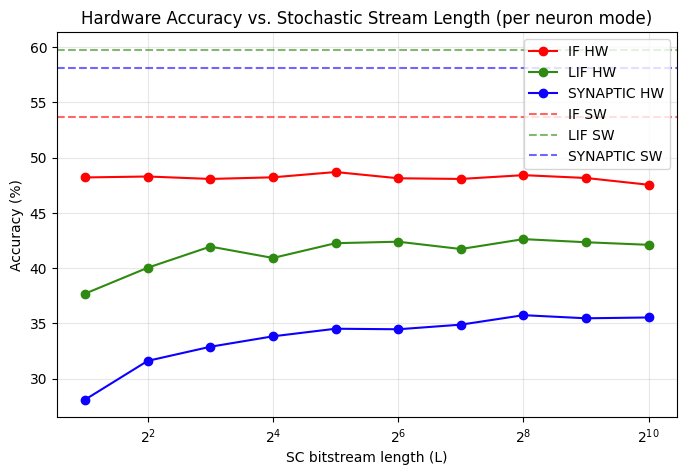

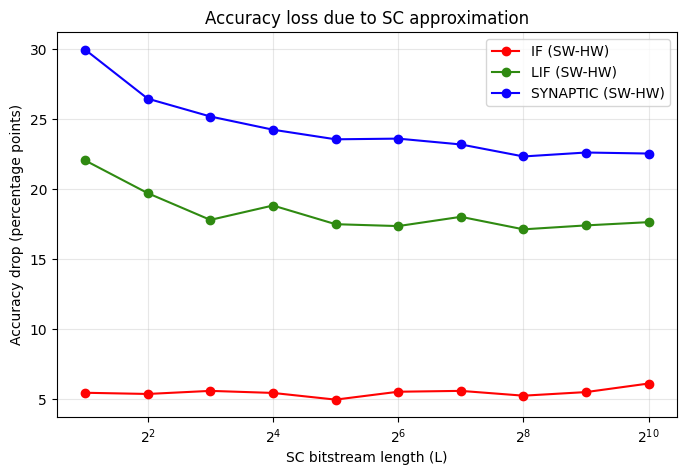

In [11]:
import matplotlib.pyplot as plt

plt.style.use("default")

plt.figure(figsize=(8,5))
for mode, c in zip(MODES, ["#ff0202ff", "#2f8a11ff", "#0d00ffff"]):
    L = np.array(results[mode]["L"])
    mean = np.array(results[mode]["mean"])
    std = np.array(results[mode]["std"])

    plt.plot(L, mean*100, marker="o", label=f"{mode.upper()} HW", color=c)
    plt.fill_between(L, (mean-std)*100, (mean+std)*100, alpha=0.2)

for mode, c in zip(MODES, ["#ff0202ff", "#2f8a11ff", "#0d00ffff"]):
    plt.axhline(results[mode]["software_acc"]*100, linestyle="--", alpha=0.6, label=f"{mode.upper()} SW", color=c)

plt.xscale("log", base=2)
plt.xlabel("SC bitstream length (L)")
plt.ylabel("Accuracy (%)")
plt.title("Hardware Accuracy vs. Stochastic Stream Length (per neuron mode)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.savefig(
    "SW_acc_HW_acc_SHD.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

plt.figure(figsize=(8,5))
for mode, c in zip(MODES, ["#ff0202ff", "#2f8a11ff", "#0d00ffff"]):
    L = np.array(results[mode]["L"])
    drop = (results[mode]["software_acc"] - np.array(results[mode]["mean"])) * 100
    plt.plot(L, drop, marker="o", label=f"{mode.upper()} (SW-HW)", color=c)

plt.xscale("log", base=2)
plt.xlabel("SC bitstream length (L)")
plt.ylabel("Accuracy drop (percentage points)")
plt.title("Accuracy loss due to SC approximation")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.savefig(
    "SW_acc_HW_acc_loss_SHD.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()